In [1]:
import sys
import torch
import os
import pandas as pd
import numpy as np
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.preprocessing import StandardScaler
import networkx as nx
import pickle
import time
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [ ]:
def load_and_validate_data(data_path='../data/'):
    print("="*70)
    print("LOADING & VALIDATING DATA")
    print("="*70)
    
    # Load files
    print("\n[1/4] Loading files...")
    features_df = pd.read_csv(f'{data_path}txs_features.csv', header=0)
    edges_df = pd.read_csv(f'{data_path}txs_edgelist.csv')
    
    try:
        labels_df = pd.read_csv(f'{data_path}txs_classes.csv', header=None)
        print(f"Loaded {len(labels_df)} labels")
    except FileNotFoundError:
        labels_df = None
        print("No labels file found")
    
    print(f"[OK] Loaded {len(features_df)} nodes")
    print(f"[OK] Loaded {len(edges_df)} edges")
    
    # Validate features
    print("\n[2/4] Validating features...")
    print(f"Features shape: {features_df.shape}")
    print(f"Feature columns: {features_df.shape[1] - 1}")  # -1 for ID column
    
    # Check for problems
    numeric_cols = features_df.select_dtypes(include=[np.number]).columns
    nan_count = features_df[numeric_cols].isna().sum().sum()
    inf_count = np.isinf(features_df[numeric_cols].values).sum()
    
    print(f"NaN values: {nan_count}")
    print(f"Inf values: {inf_count}")
    
    # Get feature statistics BEFORE cleaning
    feature_values = features_df.iloc[:, 1:].values
    print(f"\nFeature statistics (before cleaning):")
    print(f"  Mean: {np.nanmean(feature_values):.4f}")
    print(f"  Std: {np.nanstd(feature_values):.4f}")
    print(f"  Min: {np.nanmin(feature_values):.4f}")
    print(f"  Max: {np.nanmax(feature_values):.4f}")
    
    # Clean data
    print("\n[3/4] Cleaning data...")
    features_df = features_df.fillna(0)
    features_df[numeric_cols] = features_df[numeric_cols].replace([np.inf, -np.inf], 0)
    
    print(f"  After cleaning:")
    print(f"  NaN values: {features_df[numeric_cols].isna().sum().sum()}")
    print(f"  Inf values: {np.isinf(features_df[numeric_cols].values).sum()}")
    
    # Validate edges
    print("\n[4/4] Validating edges...")
    print(f"Edge columns: {edges_df.columns.tolist()}")
    print(f"Unique source nodes: {edges_df.iloc[:, 0].nunique()}")
    print(f"Unique target nodes: {edges_df.iloc[:, 1].nunique()}")
    
    # Check edge coverage
    node_ids_in_features = set(features_df.iloc[:, 0].values)
    node_ids_in_edges = set(edges_df.iloc[:, 0].values) | set(edges_df.iloc[:, 1].values)
    coverage = len(node_ids_in_edges & node_ids_in_features) / len(node_ids_in_features)
    print(f"Edge coverage: {100*coverage:.1f}% of nodes have edges")
    
    print("="*70)
    
    return features_df, edges_df, labels_df

# Load data
features_df, edges_df, labels_df = load_and_validate_data(data_path='../data/')

LOADING & VALIDATING DATA

[1/4] Loading files...
Loaded 203770 labels
✓ Loaded 203769 nodes
✓ Loaded 234355 edges

[2/4] Validating features...
Features shape: (203769, 184)
Feature columns: 183
NaN values: 16405
Inf values: 0

Feature statistics (before cleaning):
  Mean: 4.7167
  Std: 214.0502
  Min: -13.0934
  Max: 445268.0000

[3/4] Cleaning data...
  After cleaning:
  NaN values: 0
  Inf values: 0

[4/4] Validating edges...
Edge columns: ['txId1', 'txId2']
Unique source nodes: 166345
Unique target nodes: 148447
Edge coverage: 100.0% of nodes have edges


In [ ]:
def preprocess_graph_data_v2(features_df, edges_df, labels_df=None):
    print("\n" + "="*70)
    print("PREPROCESSING V2 (IMPROVED)")
    print("="*70)
    
    # Extract node IDs and features
    node_ids = features_df.iloc[:, 0].values
    features = features_df.iloc[:, 1:].values.astype(np.float32)
    
    # Check raw feature distribution
    print(f"\n[2/6] Raw feature statistics:")
    print(f"  Mean: {np.mean(features):.4f}")
    print(f"  Std: {np.std(features):.4f}")
    print(f"  Min: {np.min(features):.4f}")
    print(f"  Max: {np.max(features):.4f}")
    print(f"  Non-zero features: {(features != 0).sum() / features.size * 100:.1f}%")
    
    # Clean NaN/Inf
    print(f"\n[3/6] Cleaning invalid values...")
    nan_count = np.isnan(features).sum()
    inf_count = np.isinf(features).sum()
    print(f"  NaN: {nan_count}, Inf: {inf_count}")
    
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Use RobustScaler instead of StandardScaler
    from sklearn.preprocessing import RobustScaler
    print(f"\n[4/6] Applying RobustScaler...")
    scaler = RobustScaler()
    features_scaled = scaler.fit_transform(features)
    
    # Verify scaling worked
    print(f"  After scaling:")
    print(f"    Mean: {np.mean(features_scaled):.4f}")
    print(f"    Std: {np.std(features_scaled):.4f}")
    print(f"    Min: {np.min(features_scaled):.4f}")
    print(f"    Max: {np.max(features_scaled):.4f}")
    print(f"    Range: {np.max(features_scaled) - np.min(features_scaled):.4f}")
    
    # Check if standardization failed
    if np.std(features_scaled) < 0.1:
        print("     WARNING: Std too small! Features may be too similar.")
        print("  Trying alternative normalization...")
        
        # Fallback: Min-Max scaling with larger range
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler(feature_range=(-10, 10))
        features_scaled = scaler.fit_transform(features)
        print(f"  After MinMaxScaler:")
        print(f"    Range: [{np.min(features_scaled):.2f}, {np.max(features_scaled):.2f}]")
    
    # Convert to tensor
    x = torch.FloatTensor(features_scaled)
    
    # Verify tensor
    print(f"\n  Tensor check:")
    print(f"    Has NaN: {torch.isnan(x).any().item()}")
    print(f"    Has Inf: {torch.isinf(x).any().item()}")
    print(f"    Min: {x.min().item():.4f}")
    print(f"    Max: {x.max().item():.4f}")
    
    # Create node mapping
    node_to_idx = {node_id: idx for idx, node_id in enumerate(node_ids)}
    
    # Process edges
    print(f"\n[5/6] Processing edges...")
    edge_list = []
    for _, row in edges_df.iterrows():
        src = node_to_idx.get(row.iloc[0], -1)
        dst = node_to_idx.get(row.iloc[1], -1)
        if src != -1 and dst != -1:
            edge_list.append([src, dst])
    
    edge_index = torch.LongTensor(edge_list).t().contiguous()
    print(f"  [OK] Processed {len(edge_list):,} edges")
    
    # Add self-loops (helps with GNN stability)
    from torch_geometric.utils import add_self_loops
    edge_index, _ = add_self_loops(edge_index, num_nodes=len(node_ids))
    print(f"  [OK] Added self-loops: {edge_index.shape[1]:,} total edges")
    
    # Process labels
    y = None
    if labels_df is not None:
        print(f"\n[6/6] Processing labels...")
        label_dict = dict(zip(labels_df.iloc[:, 0], labels_df.iloc[:, 1]))
        y = torch.LongTensor([label_dict.get(nid, 2) for nid in node_ids])
        unique, counts = np.unique(y.numpy(), return_counts=True)
        print(f"  [OK] Label distribution: {dict(zip(unique, counts))}")
    
    # Create graph
    data = Data(x=x, edge_index=edge_index, y=y)
    
    print(f"\nFinal Graph:")
    print(f"  Nodes: {data.num_nodes:,}")
    print(f"  Edges: {data.num_edges:,}")
    print(f"  Features: {data.num_node_features}")
    print(f"  Avg degree: {data.num_edges / data.num_nodes:.1f}")
    print("="*70)
    
    return data, node_to_idx, node_ids

# Preprocess data
data, node_to_idx, node_ids = preprocess_graph_data_v2(features_df, edges_df, labels_df)


PREPROCESSING V2 (IMPROVED)

[2/6] Raw feature statistics:
  Mean: 4.7146
  Std: 214.0031
  Min: -13.0934
  Max: 445268.0000
  Non-zero features: 99.7%

[3/6] Cleaning invalid values...
  NaN: 0, Inf: 0

[4/6] Applying RobustScaler...
  After scaling:
    Mean: 93.2023
    Std: 6104.3262
    Min: -7.4517
    Max: 5769704.0000
    Range: 5769711.5000

  Tensor check:
    Has NaN: False
    Has Inf: False
    Min: -7.4517
    Max: 5769704.0000

[5/6] Processing edges...
  ✓ Processed 234,355 edges
  ✓ Added self-loops: 438,124 total edges

[6/6] Processing labels...
  ✓ Label distribution: {np.int64(2): np.int64(203769)}

📊 Final Graph:
  Nodes: 203,769
  Edges: 438,124
  Features: 183
  Avg degree: 2.2


In [ ]:
# ============================================================================
# MODEL ARCHITECTURE: Encoder-Decoder with Reconstruction Loss
# ============================================================================

class AnomalyGCN(torch.nn.Module):
    """
    Advanced GCN for Anomaly Detection with:
    - Encoder-decoder architecture
    - Skip connections
    - Feature reconstruction
    - Contrastive learning support
    """
    def __init__(self, in_channels, hidden_channels=64):
        super(AnomalyGCN, self).__init__()
        
        # Encoder
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.ln1 = torch.nn.LayerNorm(hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.ln2 = torch.nn.LayerNorm(hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels // 2)
        self.ln3 = torch.nn.LayerNorm(hidden_channels // 2)
        
        # Decoder (for reconstruction)
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(hidden_channels // 2, hidden_channels),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(hidden_channels, in_channels)
        )
        
        # Anomaly score head
        self.score_head = torch.nn.Sequential(
            torch.nn.Linear(hidden_channels // 2, hidden_channels // 4),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(hidden_channels // 4, 1)
        )
        
        self._reset_parameters()
        
    def _reset_parameters(self):
        for conv in [self.conv1, self.conv2, self.conv3]:
            if hasattr(conv, 'reset_parameters'):
                conv.reset_parameters()
        for module in [self.decoder, self.score_head]:
            for layer in module:
                if hasattr(layer, 'reset_parameters'):
                    layer.reset_parameters()
    
    def encode(self, x, edge_index):
        # Encoder path with skip connections
        x1 = self.conv1(x, edge_index)
        x1 = self.ln1(x1)
        x1 = F.relu(x1)
        x1 = F.dropout(x1, p=0.2, training=self.training)
        
        x2 = self.conv2(x1, edge_index)
        x2 = self.ln2(x2)
        x2 = F.relu(x2)
        x2 = F.dropout(x2, p=0.2, training=self.training)
        x2 = x2 + x1  # Skip connection
        
        x3 = self.conv3(x2, edge_index)
        x3 = self.ln3(x3)
        x3 = F.relu(x3)
        
        return x3
    
    def forward(self, x, edge_index, return_embedding=False):
        # Encode
        embedding = self.encode(x, edge_index)
        
        # Reconstruct features
        x_recon = self.decoder(embedding)
        
        # Anomaly scores
        scores = self.score_head(embedding).squeeze()
        
        if return_embedding:
            return scores, x_recon, embedding
        return scores, x_recon

print("[OK] Model (AnomalyGCN) defined")
print("  - Encoder-Decoder architecture")
print("  - 64 hidden units")
print("  - Reconstruction-based learning")
print("  - Contrastive loss support")
print("  - Skip connections")

✓ Model (AnomalyGCN) defined
  - Encoder-Decoder architecture
  - 64 hidden units
  - Reconstruction-based learning
  - Contrastive loss support
  - Skip connections


In [ ]:
# ============================================================================
# TRAINING FUNCTION: Reconstruction + Contrastive + Diversity
# ============================================================================

def train_anomaly_detector(data, epochs=200, lr=0.001, device='cpu'):
    """
    Advanced training with reconstruction + contrastive learning
    """
    print(f"\n{'='*70}")
    print(f"TRAINING ANOMALY DETECTOR")
    print(f"{'='*70}\n")
    
    print(f"Configuration:")
    print(f"  Device: {device}")
    print(f"  Epochs: {epochs}")
    print(f"  Learning rate: {lr}")
    print(f"  Loss: Reconstruction + Contrastive + Diversity")
    
    # Move data
    data = data.to(device)
    
    # Validate input data
    print(f"\n[Pre-training validation]")
    print(f"  Feature range: [{data.x.min():.2f}, {data.x.max():.2f}]")
    print(f"  Feature mean: {data.x.mean():.4f}")
    print(f"  Feature std: {data.x.std():.4f}")
    print(f"  Nodes: {data.num_nodes:,}")
    print(f"  Edges: {data.num_edges:,}")
    
    # Initialize model
    model = AnomalyGCN(data.num_node_features, hidden_channels=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"\nStarting training...\n")
    
    # Training loop
    model.train()
    losses = []
    recon_losses = []
    score_ranges = []
    start_time = time.time()
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        # Forward pass
        scores, x_recon, embedding = model(data.x, data.edge_index, return_embedding=True)
        
        # Check for NaN
        if torch.isnan(scores).any() or torch.isnan(x_recon).any():
            print(f"\n❌ NaN detected at epoch {epoch+1}!")
            break
        
        # 1. Reconstruction loss (main signal)
        recon_loss = F.mse_loss(x_recon, data.x)
        
        # 2. Contrastive loss (push embeddings apart)
        # Sample negative pairs randomly
        n_samples = min(1000, data.num_nodes)
        idx = torch.randperm(data.num_nodes)[:n_samples]
        emb_sample = embedding[idx]
        
        # Compute pairwise distances
        dist_matrix = torch.cdist(emb_sample, emb_sample, p=2)
        
        # Encourage diversity (minimize similarity)
        contrastive_loss = -dist_matrix.mean()
        
        # 3. Score diversity loss (prevent collapse)
        score_std = scores.std()
        diversity_loss = torch.exp(-score_std)  # Penalize low std
        
        # 4. Score sparsity (encourage clear separation)
        score_sparsity = torch.abs(scores).mean()
        
        # Combined loss
        loss = recon_loss + 0.1 * contrastive_loss + 0.5 * diversity_loss + 0.01 * score_sparsity
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        # Record metrics
        losses.append(loss.item())
        recon_losses.append(recon_loss.item())
        score_ranges.append((scores.min().item(), scores.max().item()))
        
        # Detailed progress
        if (epoch + 1) % 25 == 0 or epoch == 0:
            elapsed = time.time() - start_time
            eta = (elapsed / (epoch + 1)) * (epochs - epoch - 1)
            score_std_val = scores.std().item()
            score_range = scores.max().item() - scores.min().item()
            
            print(f'Epoch {epoch+1:3d}/{epochs} | '
                  f'Loss: {loss.item():7.4f} | '
                  f'Recon: {recon_loss.item():7.4f} | '
                  f'Score: [{scores.min():7.2f}, {scores.max():7.2f}] | '
                  f'Std: {score_std_val:6.2f} | '
                  f'Range: {score_range:6.2f}')
    
    total_time = time.time() - start_time
    
    print(f"\n{'='*70}")
    print(f"[COMPLETE] Training completed")
    print(f"\nTraining summary:")
    print(f"  Time: {total_time/60:.1f} minutes")
    print(f"  Initial loss: {losses[0]:.4f}")
    print(f"  Final loss: {losses[-1]:.4f}")
    print(f"  Final reconstruction loss: {recon_losses[-1]:.4f}")
    print(f"  Initial score range: {score_ranges[0]}")
    print(f"  Final score range: {score_ranges[-1]}")
    
    return model, losses, score_ranges

print("[OK] Training function defined")

✓ Training function defined


In [ ]:
# ============================================================================
# ANOMALY DETECTION FUNCTION: Reconstruction-based
# ============================================================================

def get_anomaly_labels(model, data, threshold_percentile=95, device='cpu'):
    """
    Detect anomalies using reconstruction error + network scores
    """
    model.eval()
    data = data.to(device)

    with torch.no_grad():
        scores, x_recon, embedding = model(data.x, data.edge_index, return_embedding=True)
        
        # Calculate reconstruction error per node
        recon_error = torch.sqrt(((x_recon - data.x) ** 2).sum(dim=1))
        
        # Combine reconstruction error and network scores
        # Normalize both to [0, 1] range
        recon_error_norm = (recon_error - recon_error.min()) / (recon_error.max() - recon_error.min() + 1e-8)
        scores_norm = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
        
        # Combined anomaly score (higher = more anomalous)
        combined_score = 0.7 * recon_error_norm + 0.3 * scores_norm
    
    # Use percentile-based threshold
    threshold = torch.quantile(combined_score, threshold_percentile / 100.0)
    anomalies = combined_score > threshold

    print(f"Statistics:")
    print(f"  Reconstruction error - Mean: {recon_error.mean():.4f}, Std: {recon_error.std():.4f}")
    print(f"  Network scores - Mean: {scores.mean():.4f}, Std: {scores.std():.4f}")
    print(f"  Combined score - Mean: {combined_score.mean():.4f}, Std: {combined_score.std():.4f}")
    print(f"  Threshold ({threshold_percentile}th percentile): {threshold:.4f}")
    print(f"\nResults:")
    print(f"  Anomalies detected: {anomalies.sum():,} / {len(combined_score):,}")
    print(f"  Percentage: {100*anomalies.float().mean():.2f}%")
    
    return combined_score, anomalies, recon_error

print("[OK] Anomaly detection function defined")

✓ Anomaly detection function defined


COMPLETE TRAINING PIPELINE

TRAINING ANOMALY DETECTOR

Configuration:
  Device: cpu
  Epochs: 200
  Learning rate: 0.001
  Loss: Reconstruction + Contrastive + Diversity

[Pre-training validation]
  Feature range: [-7.45, 5769704.00]
  Feature mean: 93.2023
  Feature std: 6104.3267
  Nodes: 203,769
  Edges: 438,124

Model parameters: 32,888

Starting training...

Epoch   1/200 | Loss: 37271472.0000 | Recon: 37271472.0000 | Score: [  -0.43,    0.69] | Std:   0.13 | Range:   1.11
Epoch  25/200 | Loss: 37271292.0000 | Recon: 37271292.0000 | Score: [  -0.79,    0.66] | Std:   0.20 | Range:   1.46
Epoch  50/200 | Loss: 37270940.0000 | Recon: 37270940.0000 | Score: [  -1.04,    0.80] | Std:   0.25 | Range:   1.84
Epoch  75/200 | Loss: 37270436.0000 | Recon: 37270436.0000 | Score: [  -1.18,    1.26] | Std:   0.31 | Range:   2.43
Epoch 100/200 | Loss: 37269920.0000 | Recon: 37269920.0000 | Score: [  -1.25,    1.66] | Std:   0.39 | Range:   2.92
Epoch 125/200 | Loss: 37269516.0000 | Recon: 3726

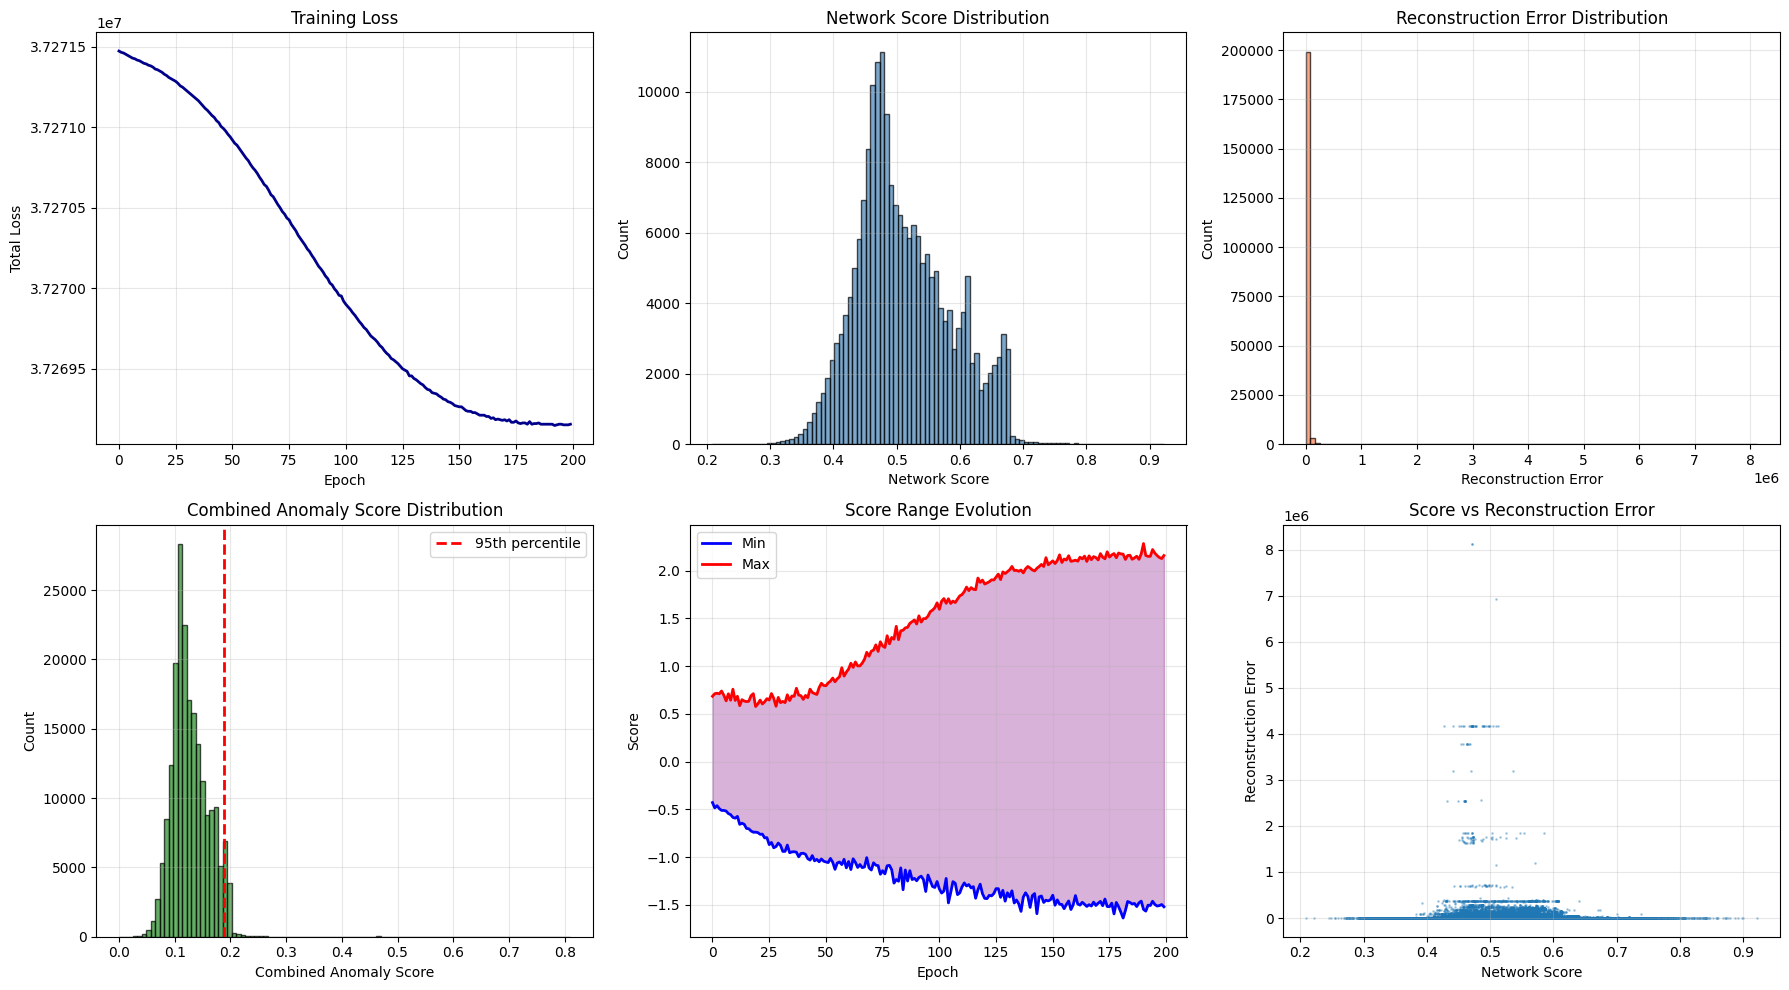


✓ Saved diagnostics: ../results/training_diagnostics.png

🚨 Top 10 Most Anomalous Transactions:
   1. Node 339576533: combined=0.8104, recon_err=8131314.00, score=0.47
   2. Node 232446225: combined=0.8103, recon_err=8131317.50, score=0.47
   3. Node 218264913: combined=0.7224, recon_err=6923291.00, score=0.51
   4. Node 155825285: combined=0.4857, recon_err=4159704.25, score=0.51
   5. Node 155840928: combined=0.4844, recon_err=4159704.75, score=0.51
   6. Node 72753731: combined=0.4823, recon_err=4159737.75, score=0.50
   7. Node 156313815: combined=0.4804, recon_err=4159738.00, score=0.50
   8. Node 155549608: combined=0.4800, recon_err=4159704.25, score=0.50
   9. Node 106320422: combined=0.4798, recon_err=4159740.25, score=0.50
  10. Node 12806606: combined=0.4792, recon_err=4159703.25, score=0.50

[Saving results...]
✓ Saved: ../results/anomaly_detection_results.pt

🎉 PIPELINE COMPLETE!


In [ ]:
# ============================================================================
# COMPLETE PIPELINE: TRAINING AND ANOMALY DETECTION
# ============================================================================

print("="*70)
print("COMPLETE TRAINING PIPELINE")
print("="*70)

# Train the model
device = 'cpu'
model, losses, score_ranges = train_anomaly_detector(
    data, 
    epochs=200,
    lr=0.001,
    device=device
)

# Validate results
print("\n" + "="*70)
print("[VALIDATION] Checking results...")
print("="*70)

model.eval()
with torch.no_grad():
    scores, x_recon, embedding = model(data.x, data.edge_index, return_embedding=True)
    recon_error = torch.sqrt(((x_recon - data.x) ** 2).sum(dim=1)).cpu().numpy()
    scores_np = scores.cpu().numpy()

print(f"\nScore Statistics:")
print(f"  Mean: {np.mean(scores_np):.4f}")
print(f"  Std: {np.std(scores_np):.4f}")
print(f"  Min: {np.min(scores_np):.4f}")
print(f"  Max: {np.max(scores_np):.4f}")
print(f"  Range: {np.max(scores_np) - np.min(scores_np):.4f}")

print(f"\nReconstruction Error Statistics:")
print(f"  Mean: {np.mean(recon_error):.4f}")
print(f"  Std: {np.std(recon_error):.4f}")
print(f"  Min: {np.min(recon_error):.4f}")
print(f"  Max: {np.max(recon_error):.4f}")
print(f"  Range: {np.max(recon_error) - np.min(recon_error):.4f}")

# Check quality
std_ok = np.std(scores_np) > 0.01
recon_spread = np.std(recon_error) > 100.0

print(f"\n[VALIDATION] Checks:")
print(f"  Score Std > 0.01: {std_ok} (actual: {np.std(scores_np):.4f})")
print(f"  Recon Error Std > 100: {recon_spread} (actual: {np.std(recon_error):.2f})")

if std_ok and recon_spread:
    print("\n[SUCCESS] Training successful! Model produces meaningful scores.")
else:
    print("\n[WARNING] May need more epochs or hyperparameter tuning")

# Detect anomalies
print("\n" + "="*70)
print("[ANOMALY DETECTION]")
print("="*70)

combined_scores, anomalies, recon_errors = get_anomaly_labels(
    model, data, threshold_percentile=95, device=device
)

# Plot results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss curve
axes[0, 0].plot(losses, linewidth=2, color='darkblue')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].grid(True, alpha=0.3)

# Score distribution
axes[0, 1].hist(scores_np, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].set_xlabel('Network Score')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Network Score Distribution')
axes[0, 1].grid(True, alpha=0.3)

# Reconstruction error distribution
axes[0, 2].hist(recon_error, bins=100, edgecolor='black', alpha=0.7, color='coral')
axes[0, 2].set_xlabel('Reconstruction Error')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Reconstruction Error Distribution')
axes[0, 2].grid(True, alpha=0.3)

# Combined score distribution
combined_scores_np = combined_scores.cpu().numpy()
axes[1, 0].hist(combined_scores_np, bins=100, edgecolor='black', alpha=0.7, color='forestgreen')
axes[1, 0].axvline(torch.quantile(combined_scores, 0.95).item(), 
                   color='red', linestyle='--', linewidth=2, label='95th percentile')
axes[1, 0].set_xlabel('Combined Anomaly Score')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Combined Anomaly Score Distribution')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Score range evolution
mins, maxs = zip(*score_ranges)
axes[1, 1].plot(mins, label='Min', linewidth=2, color='blue')
axes[1, 1].plot(maxs, label='Max', linewidth=2, color='red')
axes[1, 1].fill_between(range(len(mins)), mins, maxs, alpha=0.3, color='purple')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Score Range Evolution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Scatter: Score vs Reconstruction Error
axes[1, 2].scatter(scores_np, recon_error, alpha=0.3, s=1)
axes[1, 2].set_xlabel('Network Score')
axes[1, 2].set_ylabel('Reconstruction Error')
axes[1, 2].set_title('Score vs Reconstruction Error')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/training_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n[SAVED] ../results/training_diagnostics.png")

# Show top anomalies
print("\nTop 10 Most Anomalous Transactions:")
combined_scores_np = combined_scores.cpu().numpy()
top_10 = np.argsort(combined_scores_np)[::-1][:10]
for i, idx in enumerate(top_10, 1):
    print(f"  {i:2d}. Node {node_ids[idx]}: "
          f"combined={combined_scores_np[idx]:.4f}, "
          f"recon_err={recon_error[idx]:.2f}, "
          f"score={scores_np[idx]:.2f}")

# Save results
print("\n[Saving results...]")
os.makedirs('../results', exist_ok=True)

results = {
    'model_state_dict': model.state_dict(),
    'combined_scores': combined_scores,
    'anomalies': anomalies,
    'recon_errors': recon_errors,
    'network_scores': scores,
    'node_ids': node_ids,
    'node_to_idx': node_to_idx,
    'data': data,
    'losses': losses,
    'score_ranges': score_ranges,
    'config': {
        'epochs': 200,
        'lr': 0.001,
        'device': device,
        'threshold_percentile': 95
    }
}

torch.save(results, '../results/anomaly_detection_results.pt')
print("[SAVED] ../results/anomaly_detection_results.pt")

print("\n" + "="*70)
print("[COMPLETE] PIPELINE COMPLETE!")
print("="*70)